In [1]:
import numpy as np
import matplotlib.pyplot as plt

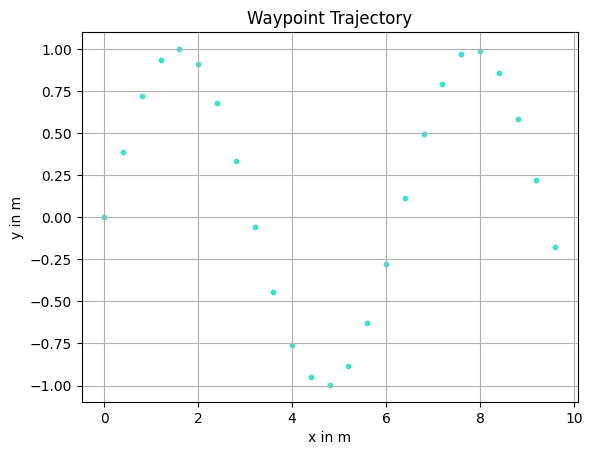

In [2]:
sim_t = 0
i = 0
dt = 0.1
y_ref = []
x_ref = []

while sim_t < 10:
    y_ref.append(np.sin(sim_t))
    x_ref.append(sim_t)
    sim_t += 0.4
    i += 1

plt.scatter(x_ref, y_ref, color='turquoise', label='Reference Signal', marker='o', s=10)
plt.xlabel('x in m')
plt.ylabel('y in m')
plt.title('Waypoint Trajectory')
plt.grid()
plt.show()
        

In [3]:
from Models.diffdrive import DiffDrive

robot = DiffDrive()
sim_t = 0
j = 0
dt = 0.01
states = []
while j < len(x_ref):
    waypoint = np.array([x_ref[j], y_ref[j]])
    omega_l, omega_r = robot.drive(waypoint)
    new_state = robot.update(omega_l, omega_r, dt)
    states.append(new_state)
    distance = np.linalg.norm(waypoint - np.array([robot.x, robot.y]))
    if distance < 0.1:  # If the robot is close to the waypoint
        j += 1
    
    sim_t += dt

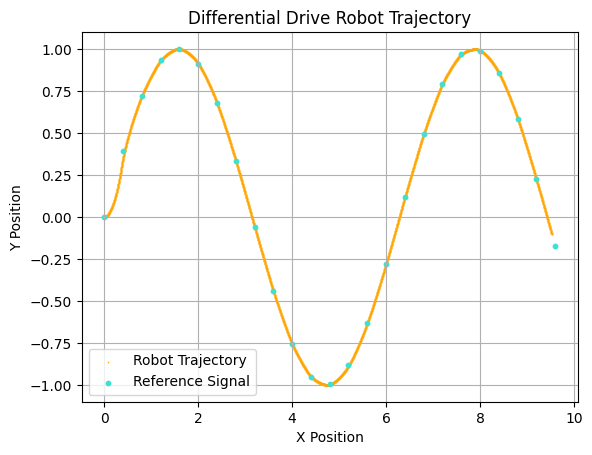

In [4]:
states = np.array(states)
plt.scatter(states[:, 0], states[:, 1], color='orange', label='Robot Trajectory', marker='x', s=0.1)
plt.scatter(x_ref, y_ref, color='turquoise', label='Reference Signal', marker='o', s=10)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Differential Drive Robot Trajectory')
plt.legend()
plt.grid()
plt.show()

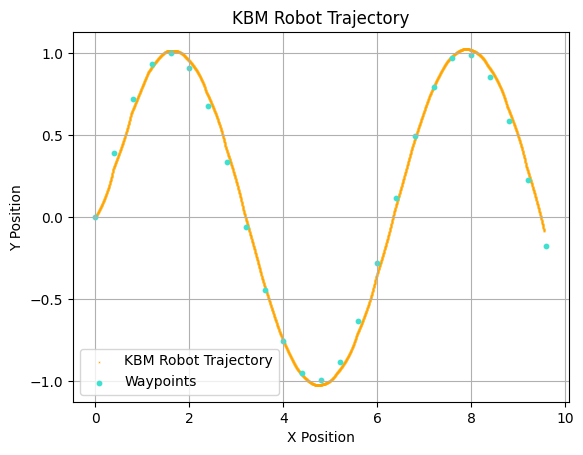

In [6]:
from Models.BicycleModel import Kinematic

robot = Kinematic(0.5, 0.5)
sim_t = 0
j = 0
dt = 0.01
states = [] 

while j < len(x_ref):
    delta_v = robot.drive(np.array([x_ref[j], y_ref[j]]))
    new_state = robot.update(delta_v, dt)
    states.append(new_state)
    distance = np.linalg.norm(np.array([x_ref[j], y_ref[j]]) - np.array([robot.x, robot.y]))
    if distance < 0.1:  # If the robot is close to the waypoint
        j += 1
    sim_t += dt

trajectory = np.array(states)
plt.scatter(trajectory[:, 0], trajectory[:, 1], color='orange', label='KBM Robot Trajectory', marker='x', s=0.1)
plt.scatter(x_ref, y_ref, color='turquoise', label='Waypoints', marker='o', s=10)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('KBM Robot Trajectory')
plt.legend()
plt.grid()
plt.show()
plt.close()